## Exploratory Data Analysis with DuckDB SQL

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns",None)

con = duckdb.connect()

In [3]:
SALES_PATH = "../data/processed/*.parquet"

In [4]:
# testing connection and reading data
df = con.execute(f"""select * from read_parquet('{SALES_PATH}') limit 5""").df()
df

,item_id,dept_id,cat_id,store_id,state_id,date,wm_yr_wk,sales,sell_price,weekday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,2011-01-29,11101,0,NaN,Saturday,1,2011,None,None,None,None,0
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,2011-01-29,11101,0,NaN,Saturday,1,2011,None,None,None,None,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,2011-01-29,11101,0,NaN,Saturday,1,2011,None,None,None,None,0
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,2011-01-29,11101,0,NaN,Saturday,1,2011,None,None,None,None,0
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,2011-01-29,11101,0,NaN,Saturday,1,2011,None,None,None,None,0


In [5]:
query = f"""

        select count(*) as rows,
                sum(sales) as total_sales,
                mean(sales) as avg_sales,
                median(sales) as median_sales,
                min(sales) as min_sales,
                max(sales) as max_sales
        from read_parquet('{SALES_PATH}')
    """

result = con.execute(query).df()
result

,rows,total_sales,avg_sales,median_sales,min_sales,max_sales
0,58327370,65695409.0,1.126322,0.0,0,763


In [6]:
query = f"""

        select count(*) as total_observations,
            count(*) filter(where sales=0) as zero_sales,
            round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct
        from read_parquet('{SALES_PATH}')
    """

result = con.execute(query).df()
result

,total_observations,zero_sales,zero_sales_pct
0,58327370,39777094,68.2



- In the entire historical dataset we have almost half of the data with zero sales which is 68.2%.
- This indicates the distribution is right skewed and very few high volume observations contributes to the entire sales.
- But we still need to explore which factors contributing to zero sales? why and when it is usually happening?

In [7]:
query = f"""

        select store_id, item_id,
            count(*) as total_observations,
            count(*) filter(where sales=0) as zero_sales,
            round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct
        from read_parquet('{SALES_PATH}')
        group by store_id,item_id
        order by store_id,item_id
    """

result = con.execute(query).df()
result

,store_id,item_id,total_observations,zero_sales,zero_sales_pct
0,CA_1,FOODS_1_001,1913,1078,56.35
1,CA_1,FOODS_1_002,1913,1278,66.81
2,CA_1,FOODS_1_003,1913,1011,52.85
3,CA_1,FOODS_1_004,1913,616,32.20
4,CA_1,FOODS_1_005,1913,1030,53.84
...,...,...,...,...,...
30485,WI_3,HOUSEHOLD_2_512,1913,1468,76.74
30486,WI_3,HOUSEHOLD_2_513,1913,1512,79.04
30487,WI_3,HOUSEHOLD_2_514,1913,1733,90.59
30488,WI_3,HOUSEHOLD_2_515,1913,1811,94.67


- At each item-store combination, around half of the sales observations are zero, indicating that many products have **intermittent sales**.


In [8]:
query = f"""

        select date,
            count(*) as total_observations,
            count(*) filter(where sales=0) as zero_sales,
            round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct
        from read_parquet('{SALES_PATH}')
        group by date
        order by date
    """

result = con.execute(query).df()
result

,date,total_observations,zero_sales,zero_sales_pct
0,2011-01-29,30490,23511,77.11
1,2011-01-30,30490,23610,77.44
2,2011-01-31,30490,24500,80.35
3,2011-02-01,30490,24518,80.41
4,2011-02-02,30490,25422,83.38
...,...,...,...,...
1908,2016-04-20,30490,18015,59.08
1909,2016-04-21,30490,18224,59.77
1910,2016-04-22,30490,17107,56.11
1911,2016-04-23,30490,15718,51.55


- Daily roughly half of the sales is zero at entire market level.
- But interestingly its very high during initial years and starts declining during 2016.
- Probably most of the earlier sales are 0 because the product was not launched yet?

In [9]:
query = f"""

        select cat_id,
            count(*) as total_observations,
            count(*) filter(where sales=0) as zero_sales,
            round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct
        from read_parquet('{SALES_PATH}')
        group by cat_id
        order by cat_id
    """

result = con.execute(query).df()
result

,cat_id,total_observations,zero_sales,zero_sales_pct
0,FOODS,27489810,17049511,62.02
1,HOBBIES,10808450,8352777,77.28
2,HOUSEHOLD,20029110,14374806,71.77


In [10]:
query = f"""

        select year,cat_id,
            count(*) as total_observations,
            count(*) filter(where sales=0) as zero_sales,
            round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct
        from read_parquet('{SALES_PATH}')
        group by year,cat_id
        order by year,cat_id
    """

result = con.execute(query).df()
result

,year,cat_id,total_observations,zero_sales,zero_sales_pct
0,2011,FOODS,4842690,3553830,73.39
1,2011,HOBBIES,1904050,1591648,83.59
2,2011,HOUSEHOLD,3528390,2849975,80.77
3,2012,FOODS,5259420,3528094,67.08
4,2012,HOBBIES,2067900,1674241,80.96
5,2012,HOUSEHOLD,3832020,2916974,76.12
6,2013,FOODS,5245050,3251050,61.98
7,2013,HOBBIES,2062250,1585246,76.87
8,2013,HOUSEHOLD,3821550,2754987,72.09
9,2014,FOODS,5245050,3048010,58.11


- During early years the zero sales percentages are quite high for each of the categories where items in the HOBBIES category are sold the least.
- But later on the sales starts increasing especially during 2016, may be sales got increased for certain items (mostly FOOD category) or may be new items got launched that started contributing to total sales? -- **need to inspect more**
- Items in **HOBBIES** category have very lesser sales (highly intermittent) probably because of the demand and need of the people.
- But need to understand the pattern when the sale actually happens for these items? is it during certain events or snap?

In [ ]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select s.store_id,s.item_id,s.date,l.launch_date,l.launch_week,s.sales,s.sell_price
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        --where s.item_id='FOODS_1_163'
        --and s.store_id='WI_3'
        
        group by s.store_id,s.item_id,s.date,l.launch_date,l.launch_week,s.sales,s.sell_price
        
        order by s.store_id,s.item_id,s.date
    """

result = con.execute(query).df()
result


# from IPython.display import display

# display(result.head(1913))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,store_id,item_id,date,launch_date,launch_week,sales,sell_price
0,CA_1,FOODS_1_001,2011-01-29,2011-01-29,11101,3,2.00
1,CA_1,FOODS_1_001,2011-01-30,2011-01-29,11101,0,2.00
2,CA_1,FOODS_1_001,2011-01-31,2011-01-29,11101,0,2.00
3,CA_1,FOODS_1_001,2011-02-01,2011-01-29,11101,1,2.00
4,CA_1,FOODS_1_001,2011-02-02,2011-01-29,11101,4,2.00
5,CA_1,FOODS_1_001,2011-02-03,2011-01-29,11101,2,2.00
6,CA_1,FOODS_1_001,2011-02-04,2011-01-29,11101,0,2.00
7,CA_1,FOODS_1_001,2011-02-05,2011-01-29,11101,2,2.00
8,CA_1,FOODS_1_001,2011-02-06,2011-01-29,11101,0,2.00
9,CA_1,FOODS_1_001,2011-02-07,2011-01-29,11101,0,2.00


In [46]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select s.store_id,s.item_id,s.date,l.launch_date,l.launch_week,s.sales,s.sell_price
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        where s.item_id='FOODS_1_163'
        and s.store_id='WI_3'
        
        --group by s.store_id,s.item_id,s.date,l.launch_date,l.launch_week,s.sales,s.sell_price
        
        order by s.store_id,s.item_id,s.date
    """

result = con.execute(query).df()
result.head(20)


# from IPython.display import display

# display(result.head(1913))


,store_id,item_id,date,launch_date,launch_week,sales,sell_price
0,WI_3,FOODS_1_163,2011-01-29,2014-05-17,11416,0,NaN
1,WI_3,FOODS_1_163,2011-01-30,2014-05-17,11416,0,NaN
2,WI_3,FOODS_1_163,2011-01-31,2014-05-17,11416,0,NaN
3,WI_3,FOODS_1_163,2011-02-01,2014-05-17,11416,0,NaN
4,WI_3,FOODS_1_163,2011-02-02,2014-05-17,11416,0,NaN
5,WI_3,FOODS_1_163,2011-02-03,2014-05-17,11416,0,NaN
6,WI_3,FOODS_1_163,2011-02-04,2014-05-17,11416,0,NaN
7,WI_3,FOODS_1_163,2011-02-05,2014-05-17,11416,0,NaN
8,WI_3,FOODS_1_163,2011-02-06,2014-05-17,11416,0,NaN
9,WI_3,FOODS_1_163,2011-02-07,2014-05-17,11416,0,NaN


- Here the food item `FOODS_1_163` was launched later on `2014-05-17` date across the store `WI_3`, hence most of the earlier sales and weekly sell prices are 0.
- This is acceptable as the product was launched quite later.
- But still the sales after product launch is intermittent.

- From the above data, we can see that food item **FOODS_1_001** in CA_1 store has been launched on `2011-01-29` and have no zero sales or null price during the launch date but has intermittent sales later on.
- The sales of the same food item is different across different stores and states.

In [61]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select 
            count(*) as total_sales,
            count(*) filter(where s.date < l.launch_date and sales=0) as zero_sales_before_launch,
            count(*) filter(where s.date >= l.launch_date and sales=0) as zero_sales_after_launch,
            round(count(*) filter(where s.date < l.launch_date and sales=0)/count(*),2) as zero_pct_before_launch,
            round(count(*) filter(where s.date >= l.launch_date and sales=0)/count(*)*100,2) as zero_pct_after_launch
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
    """

result = con.execute(query).df()
result


,total_sales,zero_sales_before_launch,zero_sales_after_launch,zero_pct_before_launch,zero_pct_after_launch
0,58327370,12299413,27477681,0.21,47.11


- Now, if we drill down further and observe that out of total sales of the walmart only `21% `of the items account for zero sales before their launch date (this is acceptable because product is not yet in the market, so no sales at all)
- But, almost `47.11%` of the total sales are `0` after the product launch which is very intermittent and need further exploration of how this can be handled at modelling level.

In [63]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select s.store_id,s.item_id,l.launch_date,
            count(*) as total_sales,
            count(*) filter(where s.date < l.launch_date and sales=0) as zero_sales_before_launch,
            count(*) filter(where s.date >= l.launch_date and sales=0) as zero_sales_after_launch,
            round(count(*) filter(where s.date < l.launch_date and sales=0)/count(*),2) as zero_pct_before_launch,
            round(count(*) filter(where s.date >= l.launch_date and sales=0)/count(*)*100,2) as zero_pct_after_launch
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        --where s.date>l.launch_date
        group by s.store_id,s.item_id,l.launch_date,
        order by s.store_id,s.item_id
    """

result = con.execute(query).df()
result[result["item_id"].str.startswith("HOBBIES")]


# from IPython.display import display

# display(result.head(1913))


,store_id,item_id,launch_date,total_sales,zero_sales_before_launch,zero_sales_after_launch,zero_pct_before_launch,zero_pct_after_launch
1437,CA_1,HOBBIES_1_001,2013-07-13,1913,896,596,0.47,31.16
1438,CA_1,HOBBIES_1_002,2011-06-18,1913,140,1371,0.07,71.67
1439,CA_1,HOBBIES_1_003,2014-02-01,1913,1099,598,0.57,31.26
1440,CA_1,HOBBIES_1_004,2011-03-05,1913,35,582,0.02,30.42
1441,CA_1,HOBBIES_1_005,2011-05-21,1913,112,838,0.06,43.81
...,...,...,...,...,...,...,...,...
29438,WI_3,HOBBIES_2_145,2011-02-12,1913,14,1579,0.01,82.54
29439,WI_3,HOBBIES_2_146,2011-01-29,1913,0,1742,0.00,91.06
29440,WI_3,HOBBIES_2_147,2013-05-25,1913,847,858,0.44,44.85
29441,WI_3,HOBBIES_2_148,2011-01-29,1913,0,1727,0.00,90.28


- After further going down with item - store combination level, we still observe very few sales are `0` before the launch date.
- But majority of the item-store combinations have `0` sales after launch date, more than `~40% `and very few items have less than `10%`
- So, even at grain level the sales are quite intermittent for the products.
- For the products under `HOBBIES` category has high zero sales percentages `(more than 70%)` compared to other categories.
- May be their sales are influenced by either seasonaility, events or snap.

In [80]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select s.store_id,s.item_id,l.launch_date,s.year,s.weekday,
            count(*) filter(where s.date >= l.launch_date) as total_sales,
            count(*) filter(where s.date >= l.launch_date and sales=0) as zero_sales_after_launch,
            round(count(*) filter(where s.date >= l.launch_date and sales=0)/count(*) filter(where s.date >= l.launch_date)*100,2) as zero_pct_after_launch
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        where s.date>=l.launch_date
        group by s.store_id,s.item_id,l.launch_date,s.year,s.weekday
        order by s.store_id,s.item_id,l.launch_date,s.year,s.weekday
    """

result = con.execute(query).df()
result[result["item_id"].str.startswith("HOBBIES")].head(100)


# from IPython.display import display

# display(result.head(1913))


,store_id,item_id,launch_date,year,weekday,total_sales,zero_sales_after_launch,zero_pct_after_launch
51857,CA_1,HOBBIES_1_001,2013-07-13,2013,Friday,24,14,58.33
51858,CA_1,HOBBIES_1_001,2013-07-13,2013,Monday,25,15,60.00
51859,CA_1,HOBBIES_1_001,2013-07-13,2013,Saturday,25,16,64.00
51860,CA_1,HOBBIES_1_001,2013-07-13,2013,Sunday,25,15,60.00
51861,CA_1,HOBBIES_1_001,2013-07-13,2013,Thursday,24,15,62.50
51862,CA_1,HOBBIES_1_001,2013-07-13,2013,Tuesday,25,12,48.00
51863,CA_1,HOBBIES_1_001,2013-07-13,2013,Wednesday,24,19,79.17
51864,CA_1,HOBBIES_1_001,2013-07-13,2014,Friday,52,34,65.38
51865,CA_1,HOBBIES_1_001,2013-07-13,2014,Monday,52,39,75.00
51866,CA_1,HOBBIES_1_001,2013-07-13,2014,Saturday,52,25,48.08


In [97]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select s.store_id,s.cat_id,s.weekday,
            count(*) filter(where s.date >= l.launch_date) as total_sales_after_launch,
            count(*) filter(where s.date >= l.launch_date and sales=0) as zero_sales_after_launch,
            round(count(*) filter(where s.date >= l.launch_date and sales=0)/count(*) filter(where s.date >= l.launch_date)*100,2) as zero_pct_after_launch
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        --where s.item_id like 'FOOD%'
        group by s.store_id,s.cat_id,s.weekday
        order by s.store_id,s.cat_id,s.weekday
    """

result = con.execute(query).df()
result.head(14)


# from IPython.display import display

# display(result.head(1913))


,store_id,cat_id,weekday,total_sales_after_launch,zero_sales_after_launch,zero_pct_after_launch
0,CA_1,FOODS,Friday,316733,147883,46.69
1,CA_1,FOODS,Monday,316733,149085,47.07
2,CA_1,FOODS,Saturday,318170,133799,42.05
3,CA_1,FOODS,Sunday,318170,135155,42.48
4,CA_1,FOODS,Thursday,316733,159144,50.25
5,CA_1,FOODS,Tuesday,316733,157772,49.81
6,CA_1,FOODS,Wednesday,316733,159171,50.25
7,CA_1,HOBBIES,Friday,124544,81991,65.83
8,CA_1,HOBBIES,Monday,124544,84084,67.51
9,CA_1,HOBBIES,Saturday,125109,75929,60.69


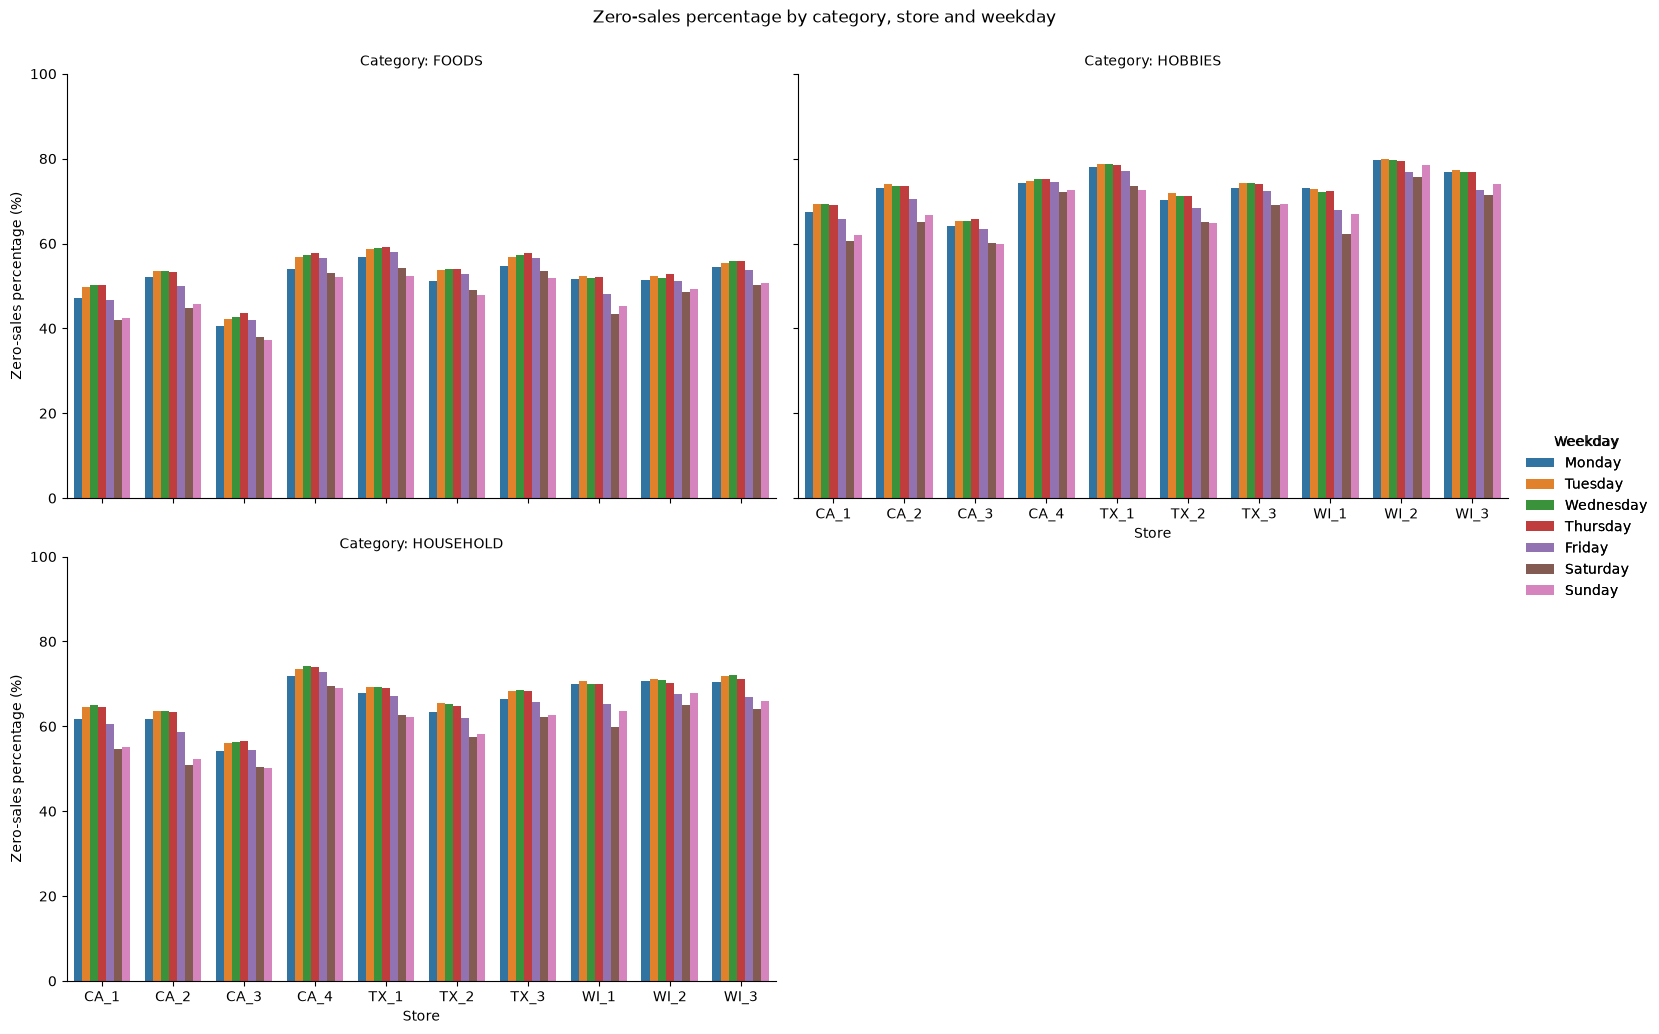

In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

plot_data = result.copy()

plot_data["weekday"] = pd.Categorical(
    plot_data["weekday"],
    categories=weekday_order,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["cat_id", "store_id", "weekday"]
)

g = sns.catplot(
    data=plot_data,
    x="store_id",                       # Level 2: Store
    y="zero_pct_after_launch",          # Metric
    hue="weekday",                     # Level 3: Weekday
    col="cat_id",                      # Level 1: Category
    kind="bar",
    col_wrap=2,
    height=5,
    aspect=1.4,
    errorbar=None
)

g.set_axis_labels(
    "Store",
    "Zero-sales percentage (%)"
)

g.set_titles(
    "Category: {col_name}"
)

g.set(ylim=(0, 100))

g.figure.suptitle(
    "Zero-sales percentage by category, store and weekday",
    y=1.03
)

g.add_legend(title="Weekday")

plt.show()

- We observe that zero sales across the stores and different categories are usually low on weekends compared to weekdays, indicating that people usually purchase items on weekends.
- On weekdays, especially in the middle of the week (Tuesday, Wednesday and Thursday) the sales are very low.

In [103]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select s.store_id,s.cat_id,s.weekday,
            count(*) filter(where s.date >= l.launch_date) as total_observations,
            count(*) filter(where s.date >= l.launch_date and sales>0) as total_sales_after_launch,
            round(count(*) filter(where s.date >= l.launch_date and sales>0)/count(*) filter(where s.date >= l.launch_date)*100,2) as sales_pct_after_launch
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        --where s.item_id like 'FOOD%'
        group by s.store_id,s.cat_id,s.weekday
        order by s.store_id,s.cat_id,s.weekday
    """

result = con.execute(query).df()
result.head(14)


# from IPython.display import display

# display(result.head(1913))


,store_id,cat_id,weekday,total_observations,total_sales_after_launch,sales_pct_after_launch
0,CA_1,FOODS,Friday,316733,168850,53.31
1,CA_1,FOODS,Monday,316733,167648,52.93
2,CA_1,FOODS,Saturday,318170,184371,57.95
3,CA_1,FOODS,Sunday,318170,183015,57.52
4,CA_1,FOODS,Thursday,316733,157589,49.75
5,CA_1,FOODS,Tuesday,316733,158961,50.19
6,CA_1,FOODS,Wednesday,316733,157562,49.75
7,CA_1,HOBBIES,Friday,124544,42553,34.17
8,CA_1,HOBBIES,Monday,124544,40460,32.49
9,CA_1,HOBBIES,Saturday,125109,49180,39.31


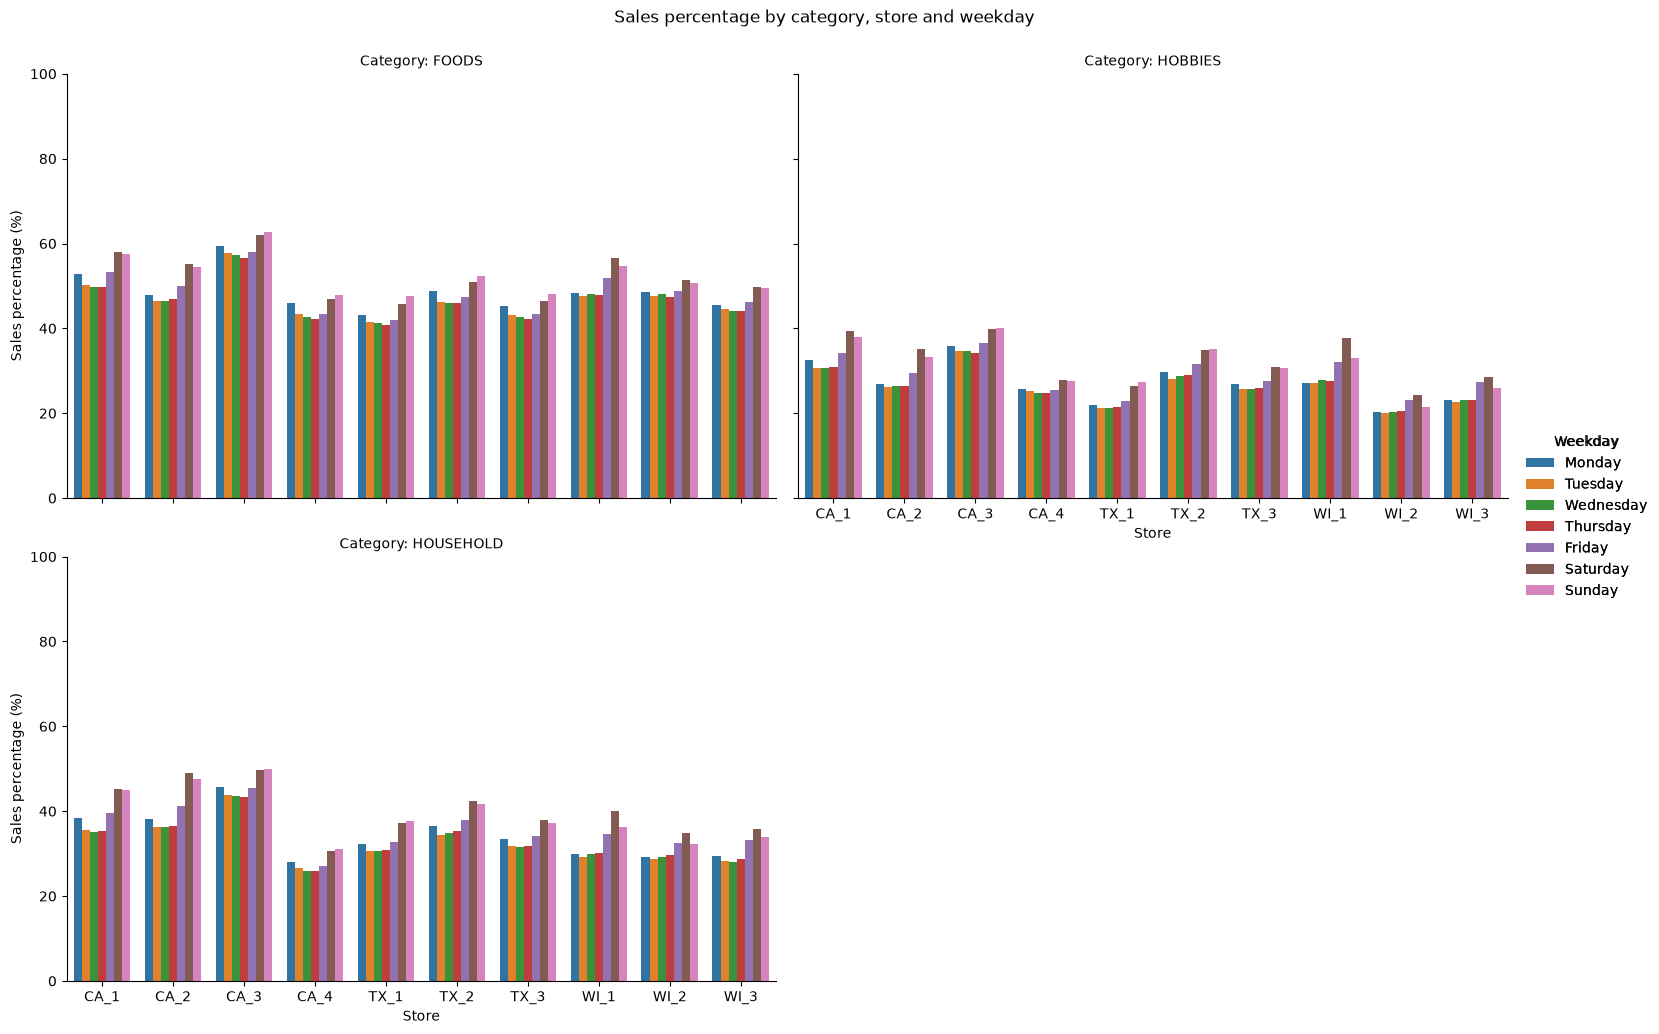

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

plot_data = result.copy()

plot_data["weekday"] = pd.Categorical(
    plot_data["weekday"], categories=weekday_order, ordered=True
)

plot_data = plot_data.sort_values(["cat_id", "store_id", "weekday"])

g = sns.catplot(
    data=plot_data,
    x="store_id",  # Level 2: Store
    y="sales_pct_after_launch",  # Metric
    hue="weekday",  # Level 3: Weekday
    col="cat_id",  # Level 1: Category
    kind="bar",
    col_wrap=2,
    height=5,
    aspect=1.4,
    errorbar=None,
)

g.set_axis_labels("Store", "Sales percentage (%)")

g.set_titles("Category: {col_name}")

g.set(ylim=(0, 100))

g.figure.suptitle("Sales percentage by category, store and weekday", y=1.03)

g.add_legend(title="Weekday")

plt.show()

- After analysing actual sales after the launch date of products at store and weekday level, we observe the same pattern that most of the sales happens on weekends i.e Friday followed by Saturday and Sunday where Saturday is the highes across almost all the categories.
- This shows the purchasing behaviour of customers.

In [114]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select s.cat_id,s.month,
            count(*) filter(where s.date >= l.launch_date) as total_observations,
            count(*) filter(where s.date >= l.launch_date and sales>0) as total_sales_after_launch,
            round(count(*) filter(where s.date >= l.launch_date and sales>0)/count(*) filter(where s.date >= l.launch_date)*100,2) as sales_pct_after_launch
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.cat_id,s.month
        order by s.cat_id,s.month
    """

result = con.execute(query).df()
result.head(36)



,cat_id,month,total_observations,total_sales_after_launch,sales_pct_after_launch
0,FOODS,1,1828708,893267,48.85
1,FOODS,2,1846121,937517,50.78
2,FOODS,3,2058238,1028308,49.96
3,FOODS,4,1933827,957688,49.52
4,FOODS,5,1672909,807818,48.29
5,FOODS,6,1641387,805412,49.07
6,FOODS,7,1712255,827032,48.30
7,FOODS,8,1730384,837585,48.40
8,FOODS,9,1690323,834274,49.36
9,FOODS,10,1764212,865352,49.05


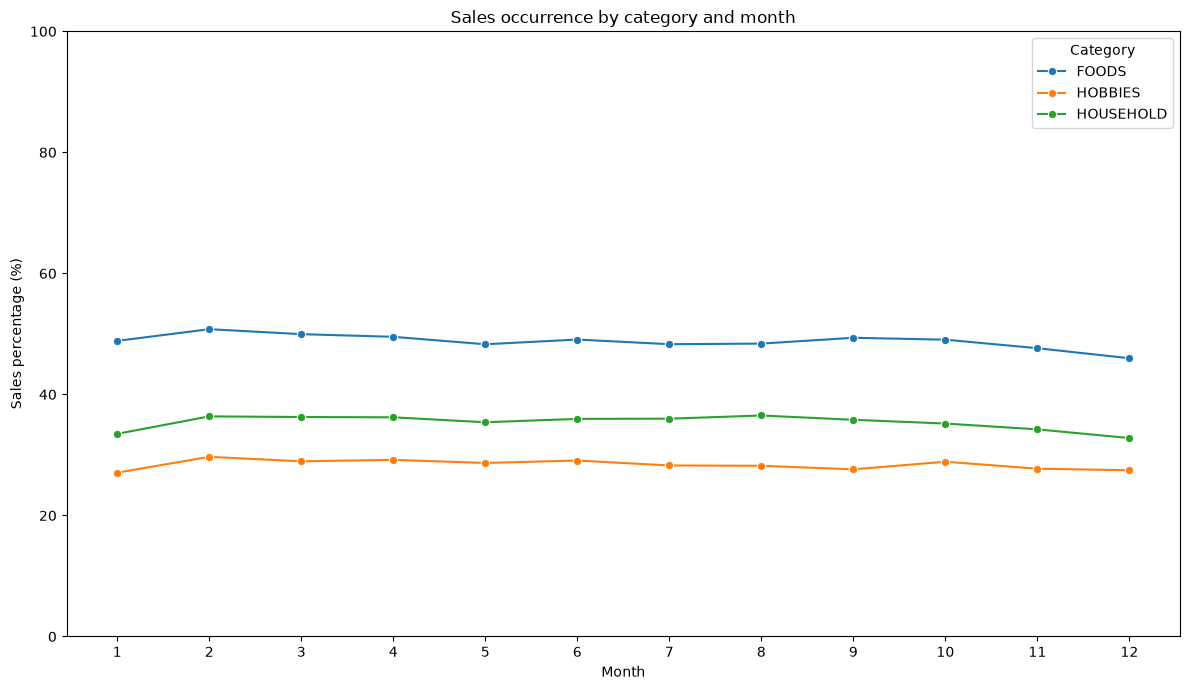

In [116]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = result.copy()

# Ensure months are in calendar order
plot_data["month"] = plot_data["month"].astype(int)

plot_data = plot_data.sort_values(
    ["cat_id", "month"]
)

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=plot_data,
    x="month",
    y="sales_pct_after_launch",
    hue="cat_id",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Sales percentage (%)")
plt.title("Sales occurrence by category and month")
plt.xticks(range(1, 13))
plt.ylim(0, 100)
plt.legend(title="Category")

plt.tight_layout()
plt.show()

- Sales of `FOOD` products are higher compared to other two categories because they are essential needs of the people.
- Sales of all the items drops down slightly during the month of Nov, Dec and Jan, indicating the impact of seasonality because these are the months where people go for christmas break and travel.
- It is quite stable for rest of the year.

In [117]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select s.store_id,s.cat_id,s.month,
            count(*) filter(where s.date >= l.launch_date) as total_observations,
            count(*) filter(where s.date >= l.launch_date and sales>0) as total_sales_after_launch,
            round(count(*) filter(where s.date >= l.launch_date and sales>0)/count(*) filter(where s.date >= l.launch_date)*100,2) as sales_pct_after_launch
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.store_id,s.cat_id,s.month
        order by s.store_id,s.cat_id,s.month
    """

result = con.execute(query).df()
result.head(36)



,store_id,cat_id,month,total_observations,total_sales_after_launch,sales_pct_after_launch
0,CA_1,FOODS,1,188616,99014,52.50
1,CA_1,FOODS,2,191913,104795,54.61
2,CA_1,FOODS,3,213996,116053,54.23
3,CA_1,FOODS,4,201369,109035,54.15
4,CA_1,FOODS,5,174692,93659,53.61
5,CA_1,FOODS,6,170822,92537,54.17
6,CA_1,FOODS,7,177912,94143,52.92
7,CA_1,FOODS,8,179941,95008,52.80
8,CA_1,FOODS,9,175795,93564,53.22
9,CA_1,FOODS,10,182685,96991,53.09


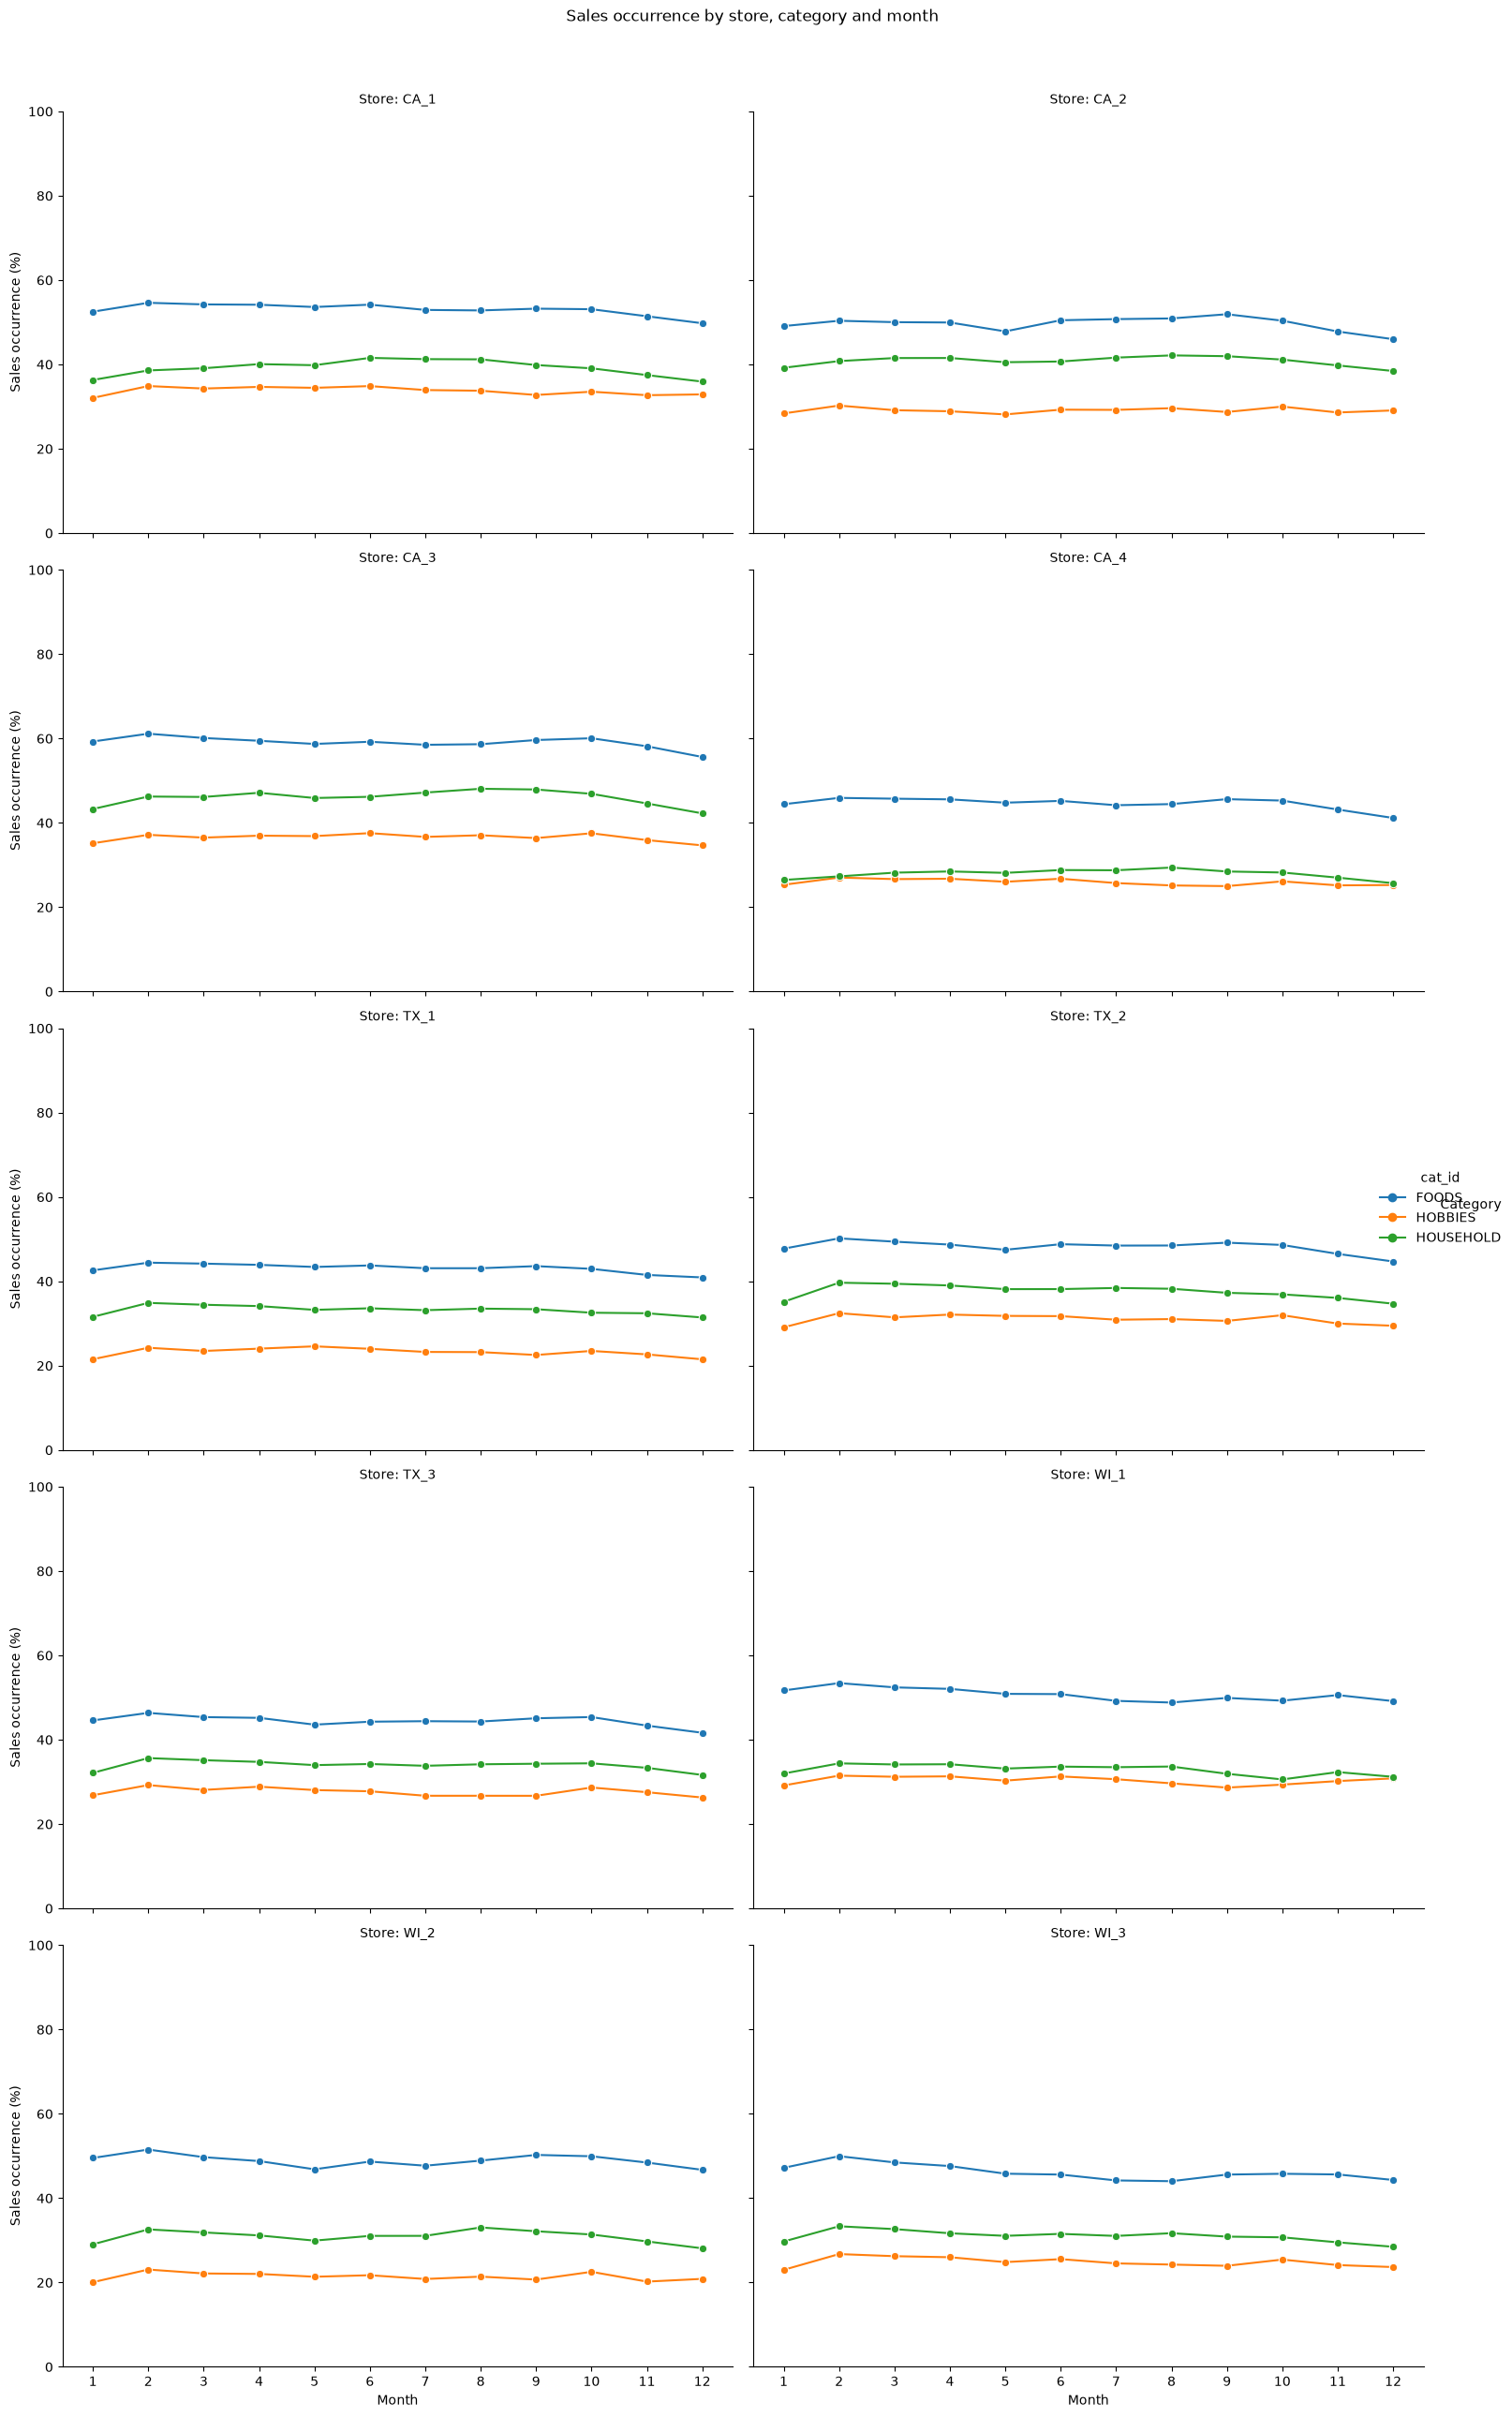

In [118]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = result.copy()

# Ensure month is ordered correctly
plot_data["month"] = plot_data["month"].astype(int)

plot_data = plot_data.sort_values(
    ["store_id", "cat_id", "month"]
)

g = sns.relplot(
    data=plot_data,
    x="month",
    y="sales_pct_after_launch",
    hue="cat_id",
    col="store_id",
    col_wrap=2,
    kind="line",
    marker="o",
    height=5,
    aspect=1.4
)

g.set_axis_labels(
    "Month",
    "Sales occurrence (%)"
)

g.set_titles(
    "Store: {col_name}"
)

g.set(
    ylim=(0, 100),
    xticks=range(1, 13)
)

g.figure.suptitle(
    "Sales occurrence by store, category and month",
    y=1.03
)

g.add_legend(title="Category")

plt.show()

- Similar patterns observed when analysed across store levels where `FOOD` products dominates the sales and `HOBBIES` contributes less.
- All the three categories have similar behaviour in all the stores where sales slighltly dropping during the month of **Nov, Dec and Jan**, indicating seasonality.
- Rest of the year, the sales remains fairly stable

### Analysing Impact of SNAP and EVENTS on Sales

In [131]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select s.snap,
            count(*) filter(where s.date >= l.launch_date) as total_observations,
            count(*) filter(where s.date>=l.launch_date and sales=0) as zero_sales,
            count(*) filter(where s.date>=l.launch_date and sales>0) as positive_sales,
            round(count(*) filter(where s.date>=l.launch_date and sales=0)/count(*) filter(where s.date >= l.launch_date),2) as zero_sales_pct,
            round(count(*) filter(where s.date>=l.launch_date and sales>0)/count(*) filter(where s.date >= l.launch_date),2) as positive_sales_pct,
            
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.snap
        order by s.snap
    """

result = con.execute(query).df()
result.head(36)



,snap,total_observations,zero_sales,positive_sales,zero_sales_pct,positive_sales_pct
0,0.0,30901211,18623934,12277277,0.60,0.40
1,1.0,15126746,8853747,6272999,0.59,0.41


- We can observe that their is slight increase in sales (by 0.01%) when their is snap event `snap=1`
- But this doesn't guarantee that snap is likely causing the sales to happen i.e no causation.
- There could be other factors contributing to sales or demand like may be some of the stores are high selling stores.
- May be sale happened on weekends when snap was active.
- May be some categories like FOOD they naturally gets sold in higher rate.

In [140]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select s.state_id,s.snap,
            count(*) filter(where s.date >= l.launch_date) as total_observations,
            round(count(*) filter(where s.date>=l.launch_date and sales=0)/count(*) filter(where s.date >= l.launch_date),2) as zero_sales_pct,
            round(count(*) filter(where s.date>=l.launch_date and sales>0)/count(*) filter(where s.date >= l.launch_date),2) as positive_sales_pct,
            
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.state_id,s.snap
        order by s.state_id,s.snap
    """

result = con.execute(query).df()
result.head(36)



,state_id,snap,total_observations,zero_sales_pct,positive_sales_pct
0,CA,0.0,12235083,0.57,0.43
1,CA,1.0,5982715,0.56,0.44
2,TX,0.0,9455143,0.62,0.38
3,TX,1.0,4631744,0.60,0.40
4,WI,0.0,9210985,0.62,0.38
5,WI,1.0,4512287,0.60,0.40


- From the above data, we can observe that the sale has increased slighlty in all the states when the snap was active.
- There is some assosciation of snap with a small increase in likelihood that the sale is happening.
- But we can't be certain that snap is causing sales to increase there could be other factors like when snap was active may be it was weekend.
- May be there were some events like christmas.
- May be seasonal pattern
- May be price got changed (decreased for certain category of essential products)

In [141]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select s.state_id,s.store_id,s.cat_id,s.snap,
            count(*) filter(where s.date >= l.launch_date) as total_observations,
            round(count(*) filter(where s.date>=l.launch_date and sales=0)/count(*) filter(where s.date >= l.launch_date),2) as zero_sales_pct,
            round(count(*) filter(where s.date>=l.launch_date and sales>0)/count(*) filter(where s.date >= l.launch_date),2) as positive_sales_pct,
            
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.state_id,s.store_id,s.cat_id,s.snap
        order by s.state_id,s.store_id,s.cat_id,s.snap
    """

result = con.execute(query).df()
result.head(36)



,state_id,store_id,cat_id,snap,total_observations,zero_sales_pct,positive_sales_pct
0,CA,CA_1,FOODS,0.0,1490632,0.48,0.52
1,CA,CA_1,FOODS,1.0,729373,0.45,0.55
2,CA,CA_1,HOBBIES,0.0,586370,0.67,0.33
3,CA,CA_1,HOBBIES,1.0,286568,0.66,0.34
4,CA,CA_1,HOUSEHOLD,0.0,1081281,0.61,0.39
5,CA,CA_1,HOUSEHOLD,1.0,528671,0.60,0.40
6,CA,CA_2,FOODS,0.0,1213831,0.51,0.49
7,CA,CA_2,FOODS,1.0,593412,0.50,0.50
8,CA,CA_2,HOBBIES,0.0,584419,0.71,0.29
9,CA,CA_2,HOBBIES,1.0,285593,0.71,0.29


- We can see that the increase in sales probability is majorly concentrated around FOOD category across all the stores and states compared to other two.
- For HOBBIES and HOUSEHOLD either the increase is very minute or there is no change at all.
- Since snap event is assosciated with food item shence there could be slight increase in sale under FOOD category.

In [150]:
query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select s.weekday,s.snap,
            round(count(*) filter(where s.date>=l.launch_date and sales>0)/count(*) filter(where s.date >= l.launch_date),2) as positive_sales_pct,
            
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.weekday,s.snap
        order by s.weekday,s.snap
    """

result = con.execute(query).df()
result = result.pivot(
    index="weekday", columns="snap", values="positive_sales_pct"
).rename(columns={0: "SNAP = 0", 1: "SNAP = 1"})
result


snap,SNAP = 0,SNAP = 1
weekday,,
Friday,0.40,0.42
Monday,0.39,0.41
Saturday,0.44,0.45
Sunday,0.43,0.45
Thursday,0.37,0.39
Tuesday,0.37,0.39
Wednesday,0.37,0.39


- Snap events are active on every day of the week, there is no strong indication that it is majorly active on either weekdays or weekends.
- Before snap, we can see that sales are slightly higher on weekends (Friday -> Monday) compared to weekdays.
- When snap is active on weekends then there is very slight increase in sales (from `44 to 45% on Saturday`).
- Weekends are naturally sales driving days hence we can't conclude that because snap was active then sale was increasing (no causation).
- But we can observe `2% increase` in sales during weekdays whenever the snap was active.
- Hence we can see that snap is having some assosciation with sales.
- But we still need to observe whether there are some other factors contributing to this like events, promotions etc.

In [ ]:

query = f"""

        with launch as (
            select item_id, store_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
            from read_parquet('{SALES_PATH}')
            where sell_price is not null
            group by item_id,store_id
        )
        select 
            case 
                when s.event_type_1=='No Event' then 'No Event'
                else 'Event'
            end as event_type
            ,s.snap,
            round(count(*) filter(where s.date>=l.launch_date and sales>0)/count(*) filter(where s.date >= l.launch_date),2) as positive_sales_pct,
            
        from read_parquet('{SALES_PATH}') as s
        join launch as l
            on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by event_type,s.snap
        order by event_type,s.snap
    """

result = con.execute(query).df()
result = result.pivot(index="event_type",columns="snap",values="positive_sales_pct").rename(columns={"0.0":"SNAP = 0","1.0":"SNAP = 1"})
result



snap,0.0,1.0
event_type,,
Event,0.37,0.41
No Event,0.40,0.42


- Event alone is not increasing the likeliohood of sales, but when the snap is active then the sales got increased by `+4%` (from 37% to 41%)
- Snap is assosciated with slightly higher likelihood of sales irrespective of wether event is happening or not.
- Because when the `snap = 0` the sales is `37%` during event but when `snap=1` then sales got increased to `41%`
- Same during non event days, when `snap=0` the sales is `40%` but when snap got activated then sale got increased to `42%`.

In [13]:
query = f"""
        select store_id,
            sum(sales) as total_sales,
            avg(sales) as avg_sales
        from read_parquet('{SALES_PATH}')
        group by store_id
"""

result = con.execute(query).df()
result

,store_id,total_sales,avg_sales
0,CA_2,5685475.0,0.974753
1,CA_1,7698216.0,1.319829
2,TX_3,6089330.0,1.043992
3,WI_3,6427782.0,1.102018
4,TX_2,7214384.0,1.236878
5,TX_1,5595292.0,0.959291
6,WI_1,5149062.0,0.882787
7,CA_4,4103676.0,0.703559
8,WI_2,6544012.0,1.121945
9,CA_3,11188180.0,1.918170


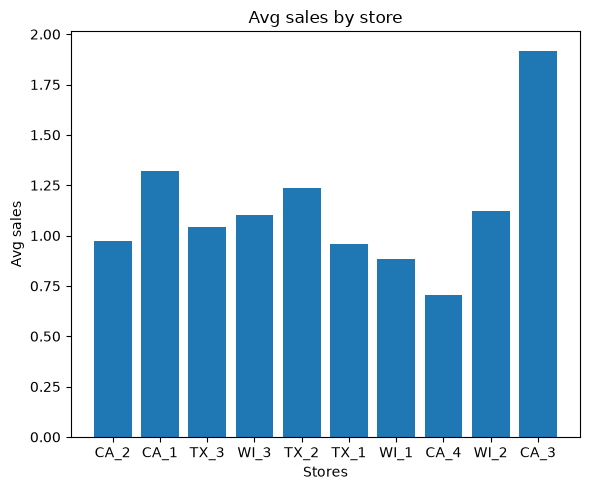

In [14]:
plt.figure(figsize=(6,5))
plt.bar(result["store_id"],result["avg_sales"])

plt.title("Avg sales by store")
plt.xlabel("Stores")
plt.ylabel("Avg sales")

plt.tight_layout()
plt.show()

In [15]:
query = f"""
        select state_id,
            sum(sales) as total_sales,
            avg(sales) as avg_sales
        from read_parquet('{SALES_PATH}')
        group by state_id
"""

result = con.execute(query).df()
result

,state_id,total_sales,avg_sales
0,WI,18120856.0,1.035583
1,CA,28675547.0,1.229078
2,TX,18899006.0,1.080054


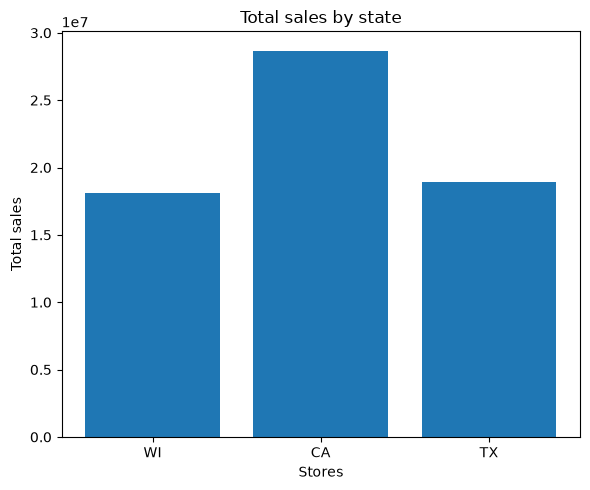

In [16]:
plt.figure(figsize=(6,5))
plt.bar(result["state_id"],result["total_sales"])

plt.title("Total sales by state")
plt.xlabel("Stores")
plt.ylabel("Total sales")

plt.tight_layout()
plt.show()

In [17]:
query = f"""
        select cat_id,
            sum(sales) as total_sales,
            avg(sales) as avg_sales
        from read_parquet('{SALES_PATH}')
        group by cat_id
"""

result = con.execute(query).df()
result

,cat_id,total_sales,avg_sales
0,HOUSEHOLD,14480670.0,0.722981
1,FOODS,45089939.0,1.640242
2,HOBBIES,6124800.0,0.566668


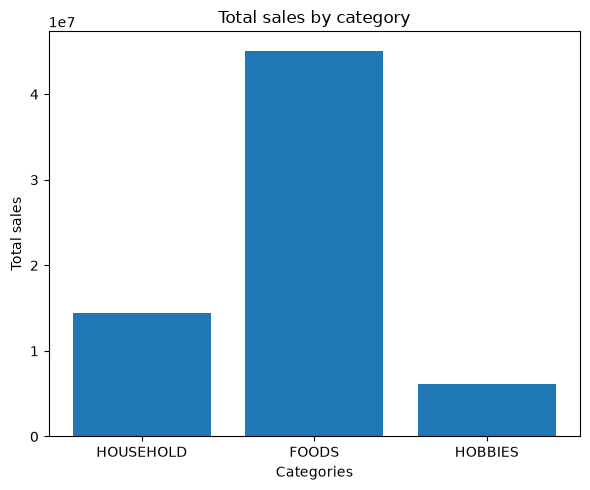

In [18]:
plt.figure(figsize=(6,5))
plt.bar(result["cat_id"],result["total_sales"])

plt.title("Total sales by category")
plt.xlabel("Categories")
plt.ylabel("Total sales")

plt.tight_layout()
plt.show()

In [19]:
query = f"""
        select dept_id,
            sum(sales) as total_sales,
            avg(sales) as avg_sales
        from read_parquet('{SALES_PATH}')
        group by dept_id
"""

result = con.execute(query).df()
result

,dept_id,total_sales,avg_sales
0,FOODS_2,7629822.0,1.002112
1,HOUSEHOLD_2,2980144.0,0.302493
2,HOUSEHOLD_1,11500526.0,1.130033
3,HOBBIES_1,5596460.0,0.703242
4,HOBBIES_2,528340.0,0.185358
5,FOODS_1,5088041.0,1.231351
6,FOODS_3,32372076.0,2.056155


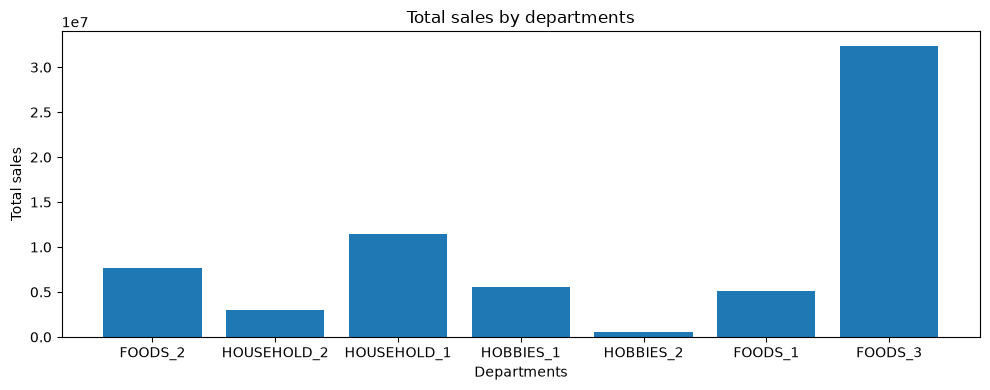

In [20]:
plt.figure(figsize=(10,4))
plt.bar(result["dept_id"],result["total_sales"])

plt.title("Total sales by departments")
plt.xlabel("Departments")
plt.ylabel("Total sales")

plt.tight_layout()
plt.show()

In [21]:
# Yearly sales

query = f"""
        select year,
            sum(sales) as total_sales,
        from read_parquet('{SALES_PATH}')
        group by year
        order by year
"""

result = con.execute(query).df() 
result

,year,total_sales
0,2011,8856585.0
1,2012,12061837.0
2,2013,13135753.0
3,2014,13089776.0
4,2015,13800811.0
5,2016,4750647.0


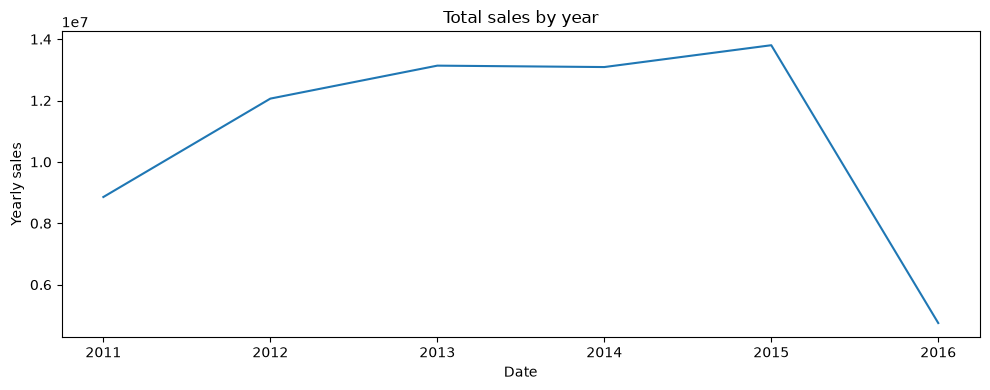

In [22]:
plt.figure(figsize=(10,4))
plt.plot(result["year"],result["total_sales"])

plt.title("Total sales by year")
plt.xlabel("Date")
plt.ylabel("Yearly sales")

plt.tight_layout()
plt.show()

In [23]:
# Monthly sales

query = f"""
        select month,
            sum(sales) as total_sales,
        from read_parquet('{SALES_PATH}')
        group by month
        order by month
"""

result = con.execute(query).df() 
result

,month,total_sales
0,1,5345511.0
1,2,5889589.0
2,3,6387210.0
3,4,5961011.0
4,5,5038097.0
5,6,5250212.0
6,7,5443975.0
7,8,5571730.0
8,9,5321889.0
9,10,5380589.0


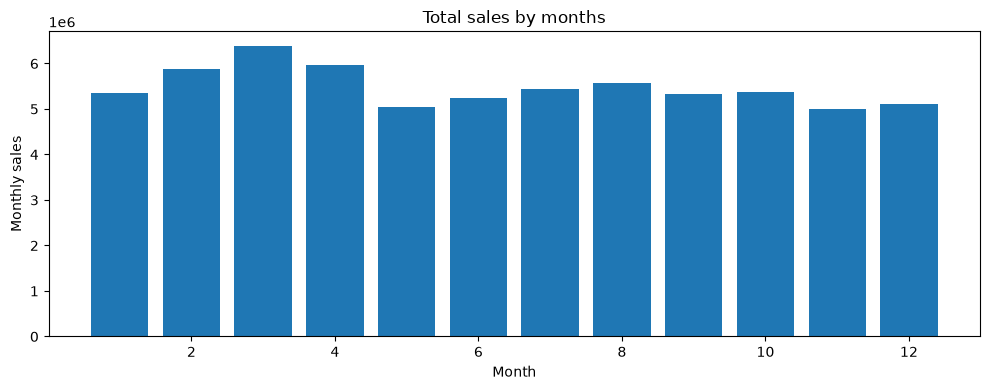

In [24]:
plt.figure(figsize=(10,4))
plt.bar(result["month"],result["total_sales"])

plt.title("Total sales by months")
plt.xlabel("Month")
plt.ylabel("Monthly sales")

plt.tight_layout()
plt.show()

In [25]:
# Weekly sales

query = f"""
        select weekday as week,
            sum(sales) as total_sales,
        from read_parquet('{SALES_PATH}')
        group by week
        order by week
"""

result = con.execute(query).df() 
result

,week,total_sales
0,Friday,9343694.0
1,Monday,8968860.0
2,Saturday,11383849.0
3,Sunday,11269626.0
4,Thursday,8245967.0
5,Tuesday,8290677.0
6,Wednesday,8192736.0


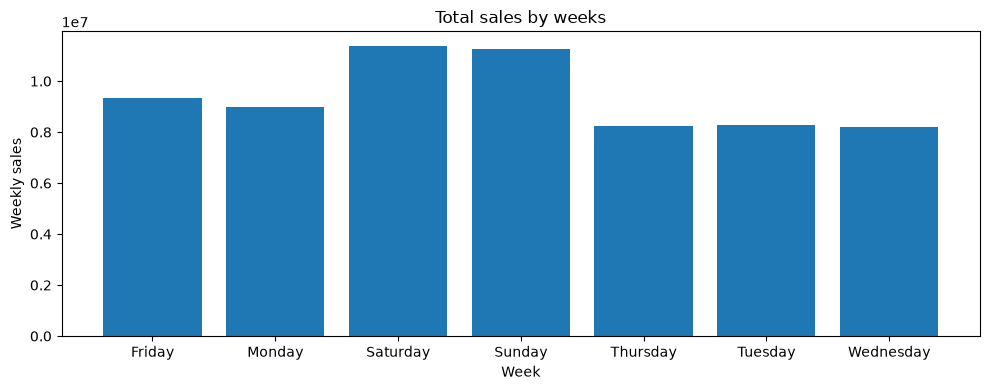

In [26]:
plt.figure(figsize=(10,4))
plt.bar(result["week"],result["total_sales"])

plt.title("Total sales by weeks")
plt.xlabel("Week")
plt.ylabel("Weekly sales")

plt.tight_layout()
plt.show()

In [27]:
# Daily sales

query = f"""
        select date,
            sum(sales) as total_sales,
        from read_parquet('{SALES_PATH}')
        group by date
        order by date
"""

result = con.execute(query).df() 
result

,date,total_sales
0,2011-01-29,32631.0
1,2011-01-30,31749.0
2,2011-01-31,23783.0
3,2011-02-01,25412.0
4,2011-02-02,19146.0
5,2011-02-03,29211.0
6,2011-02-04,28010.0
7,2011-02-05,37932.0
8,2011-02-06,32736.0
9,2011-02-07,25572.0


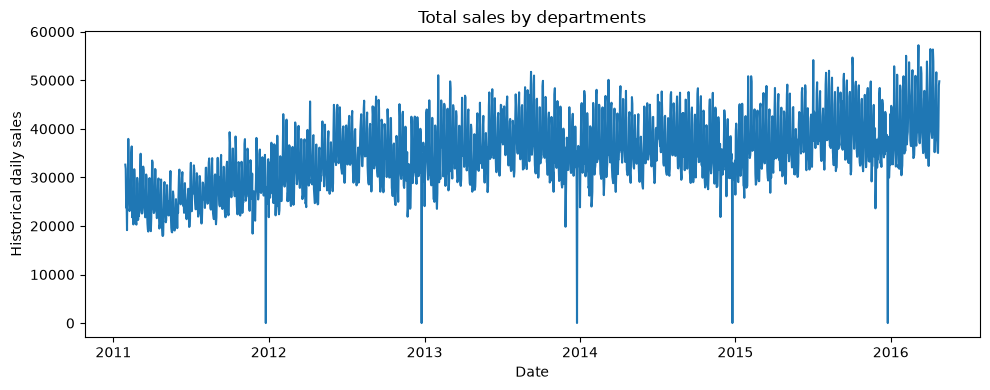

In [28]:
plt.figure(figsize=(10,4))
plt.plot(result["date"],result["total_sales"])

plt.title("Total sales by departments")
plt.xlabel("Date")
plt.ylabel("Historical daily sales")

plt.tight_layout()
plt.show()

In [29]:
# Daily sales

query = f"""
        select event_type_1,
            count(*) as total_event_count,
            sum(sales) as total_sales,
            avg(sales) as avg_sales
        from read_parquet('{SALES_PATH}')
        group by event_type_1
        
"""

result = con.execute(query).df() 
result["event_type_1"] = result["event_type_1"].fillna("No event")
result

,event_type_1,total_event_count,total_sales,avg_sales
0,Sporting,487840,572737.0,1.174026
1,National,1554990,1502384.0,0.966170
2,Cultural,1067150,1198216.0,1.122819
3,Religious,1585480,1755556.0,1.107271
4,No event,53631910,60666516.0,1.131165


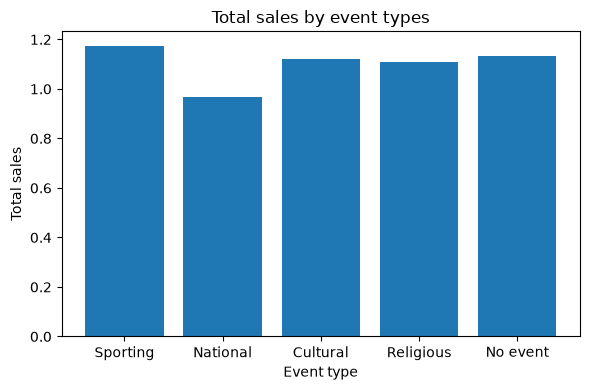

In [30]:
plt.figure(figsize=(6,4))
plt.bar(result["event_type_1"],result["avg_sales"])

plt.title("Total sales by event types")
plt.xlabel("Event type")
plt.ylabel("Total sales")

plt.tight_layout()
plt.show()